# Regression using K-NN


## Prerequisites

Students require knowledge of following topics before starting this read:

- Introduction to K-NN and K-NN classifier.


## Learning Objective

1. Distinguish working of K-NN regression in comparision to K-NN classifier.
2. Build K-NN regression using Numpy module.
3. Contrast KNN regression with linear regression model.
4. Point out few applications of K-NN regression.
5. List the pros and cons of K-NN algorithm.



Previously, you studied K-NN based classifier. This time we are learning K-NN based regression algorithm, comparing it with linear regression model, and finally discussing the pros and cons of K-NN algorithm. Let's get started.


## K-NN regression

K-NN regression's training phase is exactly same as K-NN classifier, where the dataset is stored either directly or using advanced data structure. However, K-NN regression uses __aggregation scheme__ for prediction of real-valued target of unseen sample. After setting the hyperparameters and traing phase, the prediction phase for K-NN regression looks as:

- Prediction phase

  Given a test sample $\mathbf{x}_t$,
  
  1. Compute its "K"-nearest neighbors set, $S_{\mathbf{x}_t}$.
     
  2. Predict the target value of the test sample, $h(\mathbf{x}_t)$ by taking the mean of the target values($y''$) present in $S_{\mathbf{x}_t}$. Mathematically,
       
     $$\boxed{h(\mathbf{x}_t) = \frac{\sum_{y'' \in S_{\mathbf{x}_t}} y''}{K}}$$
     
Now, let's build a KNN-regression (brute-force implemenetation) using Numpy module(only Euclidean distance available as distance function).


## Implementation of K-NN regression

Since, most of the functions are similar to K-NN classifier, we are using object-oriented paradigm instead of functional paradigm for shorter implementation of K-NN regression.

The main methods of class ```Knnregression``` are:

1. ```fit```: Stores the training dataset.

Instead of computing euclidean distances between elements using ```for``` loops that is time-consuming, we are defining function,

2. ```_calculate_euc_dist_mat```: Computes the Euclidean distance between two feature vectors are return an Euclidean matrix, similar to sklearn's ```metrics.euclidean_distances``` method.

 Let's briefly discuss about euclidean distance matrix and how to construct it. The Euclidean distance matrix between two feature vectors, 

 $$A = \begin{pmatrix}
a_{11} & a_{12} & \cdots & a_{1m} \\
a_{21} & a_{22} & \cdots & a_{2m} \\
\vdots & \vdots & \ddots & \vdots \\
a_{n1} & a_{n2} & \cdots & a_{nm} \\
\end{pmatrix}_{\text{(nxm)}} \text{and} \ B=\begin{pmatrix}
b_{11} & b_{12} & \cdots & b_{1m} \\
b_{21} & b_{22} & \cdots & b_{2m} \\
\vdots & \vdots & \ddots & \vdots \\
b_{z1} & b_{z2} & \cdots & b_{zm} \\
\end{pmatrix}_{\text{(zxm)}}$$ is given as:

 $$
D = \begin{pmatrix}
d_{11} & d_{12} & \cdots & d_{1z} \\
d_{21} & d_{22} & \cdots & d_{2z} \\
\vdots & \vdots & \ddots & \vdots \\
d_{n1} & d_{n2} & \cdots & d_{nz} \\
\end{pmatrix}_{\text{(nxz)}} 
$$

 Where,
 - Feature vector $A$ contains $n$ data samples and $m$ features per sample. Similarly, $B$ contains $z$ data samples with $m$ features per sample. 

 - $a_{ij}, b_{ij} = j^{\text{th}}$ feature of $i^{\text{th}}$ sample of feature vectors $A$ and $B$, respectively.

 - $d_{11}$ represent Euclidean distance between 1st data samples of $A$ and $B$, $d_{12}$ between 1st, 2nd data samples of $A$ and $B$ and so on. Consequently, the Euclidean distance matrix has dimension $n \times z$.

 Instead of computing $D$, we will compute  __squared euclidean distance matrix__ ($D^2$) because each element of $D^2$, i.e., $d_{ij}^2$ can be computed as sum of three components that are:

 1. Squared L2 norm of $i^{th}$ row of vector $A$, $||a_i||_{2}^2 = \sum_{k=1}^{m}a_{ik}^2$,
 2. Squared L2 norm of $j^{th}$ row of vector $B$$, ||b_j||_2^2=\sum_{k=1}^{m}b_{jk}^2$, and 
 3. $-2a_ib_j^T= \sum_{k=1}^m-2a_{ik}b_{jk}$. 

 The elements of $D^2$:

 $$
D^2 = \begin{pmatrix}
d^2_{11} & d^2_{12} & \cdots & d^2_{1z} \\
d^2_{21} & d^2_{22} & \cdots & d^2_{2z} \\
\vdots & \vdots & \ddots & \vdots \\
d^2_{n1} & d^2_{n2} & \cdots & d^2_{nz} \\
\end{pmatrix}_{\text{(nxz)}} 
$$

 can be represented as:

 $$ D^2 = \begin{pmatrix}
||a_1||_{2}^2+||b_1||_2^2 - 2a_1b_1^T& ||a_1||_{2}^2+||b_2||_2^2 - 2a_1b_2^T & \cdots & ||a_1||_{2}^2+||b_z||_2^2 - 2a_1b_z^T \\
||a_2||_{2}^2+||b_1||_2^2 - 2a_2b_1^T & ||a_2||_{2}^2+||b_2||_2^2 - 2a_2b_2^T & \cdots & ||a_2||_{2}^2+||b_z||_2^2 - 2a_2b_z^T \\
\vdots & \vdots & \ddots & \vdots \\
||a_n||_{2}^2+||b_1||_2^2 - 2a_nb_1^T & ||a_n||_{2}^2+||b_2||_2^2 - 2a_nb_2^T & \cdots & ||a_n||_{2}^2+||b_z||_2^2 - 2a_nb_z^T \\
\end{pmatrix}_{\text{(nxz)}}$$

 In the implementation, we compute $D^2$ by first defining/computing three components and adding them, the components being:

 1. Column vector, $||\mathbf{a}||_2^2 =\begin{pmatrix}||a_1||_{2}^2 \\ ||a_2||_{2}^2 \\ \vdots \\ ||a_n||_{2}^2 \end{pmatrix}_{(n \times 1)}$

 2. Row vector , ${||\mathbf{b}||_2^2}^T =\begin{pmatrix}||b_1||_{2}^2 & ||b_2||_{2}^2 & \cdots & ||b_z||_{2}^2 \end{pmatrix}_{(1 \times z)}$ 

 3. Matrix, $W = \begin{pmatrix}
- 2a_1b_1^T&  - 2a_1b_2^T & \cdots &  - 2a_1b_z^T \\
- 2a_2b_1^T & - 2a_2b_2^T & \cdots &  - 2a_2b_z^T \\
\vdots & \vdots & \ddots & \vdots \\
- 2a_nb_1^T & - 2a_nb_2^T & \cdots &  - 2a_nb_z^T \\
\end{pmatrix}_{\text{(nxz)}}$ 

 Finally for computing euclidean distance matrix($D$), we take the square root of the sum as:

 $$\boxed{D = \sqrt{D^2} =  \sqrt{||\mathbf{a}||_2^2+{||\mathbf{b}||_2^2}^T+W}}$$

 To know about the more about the math behind the computing this matrix, follow this blogpost on [Euclidean distance matrix]( https://medium.com/swlh/euclidean-distance-matrix-4c3e1378d87f) by Andrea Grianti.

3. ```predict```: computes the predicted target labels for the new unseen samples using aggregation scheme. This method is similar to predict function of K-NN classifier implemented previously.

Below is the code for implementation of class ```Knnregression```.


In [ ]:
import numpy as np # Importing required module

class Knnregression():
    """

    K-NN based regression 
    
    This is a K-NN regression built using Numpy module that
    only supports numerical data as input and euclidean distance 
    for computing neighbors.
    """
    
    def __init__(self, k):
        '''
        Constructs K attribute of K-NN regression
        
        Parameters
        ----------
        k: int
          Number of neighbors to take into account in K-NN
        '''
        
        self.k = k
        
    def fit(self, X_train, y_train):
        '''
        Trains the K-NN model, i.e. storing the training dataset
        
        Parameters
        ----------
        X_train: Numpy.array, shape(n,m)
                Training feature matrix
        y_train: Numpy.array, shape(n,)
                Training target values
        '''
        
        self.X_train = X_train
        self.y_train = y_train
        
    def _calculate_euc_dist_mat(self, X_test):
        '''
        Computes the euclidean distance matrix between two feature vectors
        
        Parameters
        ----------
        X_test: Numpy.array, shape(z,m)
            New feature matrix, this feature vector and stored one's euclidean 
            distance is computed.
            
        Returns
        -------
        euc_mat: Numpy.array, shape(n,z)
            Euclidean distance matrix, here element (1,1) is euclidean distance 
            between stored data's 1st sample and new data's 1st sample, (1,2) 
            between stored data's 1st sample and new data's 2nd sample and so on.      
        '''
        a = np.sum(self.X_train**2, axis=1).reshape(-1,1) # Reshaping for proper euclidean matrix.
        b_T = np.sum(X_test**2, axis=1)
        W = -2 * np.dot(self.X_train,X_test.T)
        euc_mat = np.sqrt(a + b_T + W + 1e-10) # Adding small value to avoid warning.
        
        return euc_mat
        
    def predict(self, X_test):
        '''
        Predicts the target labels of provided data
        
        Parameters
        ----------
        X_test: Numpy.array, shape(z,m)
        
        Returns
        -------
        np.array(self.predictions): Numpy,array, shape(z,)
                Predictions of the target labels
        '''
            
        self.predictions = []
        
        dist_mat = self._calculate_euc_dist_mat(X_test)
        
        for i in range(X_test.shape[0]):
            distance = dist_mat[:,i] # Taking ith column of distance matrix
            near_neigh_index = np.argsort(distance)[:self.k]
            near_neigh_labels = self.y_train[near_neigh_index]
            
            self.predictions.append(np.mean(near_neigh_labels)) # Aggregation
        
        return np.array(self.predictions)

Now, let's test the performance of our K-NN regression model on _Boston house price prediction_ dataset available in Scikit-learn.


### Importing data and feature scaling

First, we need to import the the boston house data. Then, continue with feature scaling on the input feature matrix ```X``` and finally split the dataset into train and test set. Feature scaling is mandatory preprocessing step for K-NN based algorithm because of their dependency on distance function. As the unscaled features degrade the performance of K-NN model, we will be using ```MinMaxScaler``` provided by Scikit-learn to limit the values of features between 0 and 1. 


In [ ]:
from sklearn.datasets import load_boston
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

X, y = load_boston(return_X_y=True)

X_scaled = MinMaxScaler().fit_transform(X) 

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y 
                                                    , test_size=0.2
                                                    , random_state=42)

### Fitting the K-NN regression and prediction

Like Scikit-learn's estimator, we will create instance of our class ```Knnregression```, fit the training data and finally predict the output target values. Let's take four neighbors into account while predicting the target value,, i.e. set $K=4$.


In [ ]:
knn_reg = Knnregression(k=4) 
knn_reg.fit(X_train, y_train)

knn_y_train_pred = knn_reg.predict(X_train)
knn_y_test_pred = knn_reg.predict(X_test)

### Performance comparision with linear regression

Using MSE as the performance metric, let's compare the training and test MSE for both K-NN regression and linear regression model.


In [ ]:
from sklearn.metrics import mean_squared_error

knn_train_error = mean_squared_error(y_train, knn_y_train_pred)
knn_test_error = mean_squared_error(y_test, knn_y_test_pred)

print(f'KNN, Training MSE: {knn_train_error:.2f}')
print(f'KNN, Test MSE: {knn_test_error:.2f}')

KNN, Training MSE: 11.91
KNN, Test MSE: 19.80


Now, let's fit linear regression model and compute MSE on training and test set.


In [ ]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

lin_reg.fit(X_train, y_train)

lin_y_train_pred = lin_reg.predict(X_train)
lin_y_test_pred = lin_reg.predict(X_test)

lin_train_error = mean_squared_error(y_train, lin_y_train_pred)
lin_test_error = mean_squared_error(y_test, lin_y_test_pred)

print(f'Linear Regression, Training MSE: {lin_train_error:.2f}')
print(f'Linear Regression, Test MSE: {lin_test_error:.2f}')

Linear Regression, Training MSE: 21.64
Linear Regression, Test MSE: 24.29


The MSE errors for K-NN regression and linear regression model are around the same range, with slightly better performance of K-NN. Our implementation of K-NN regression is working as expected. Now, let's check the decision function of K-NN regression on a synthetic dataset.


## Decision function of K-NN regression

Figure 1 present below illustrates the fit of K-NN regression with $K=4$ and Euclidean distance metric on a linear synthetic dataset with a single feature $\mathbf{x}$, and continuous target variable $y=2\mathbf{x}+\text{noise}$.

<center>


<p><img src="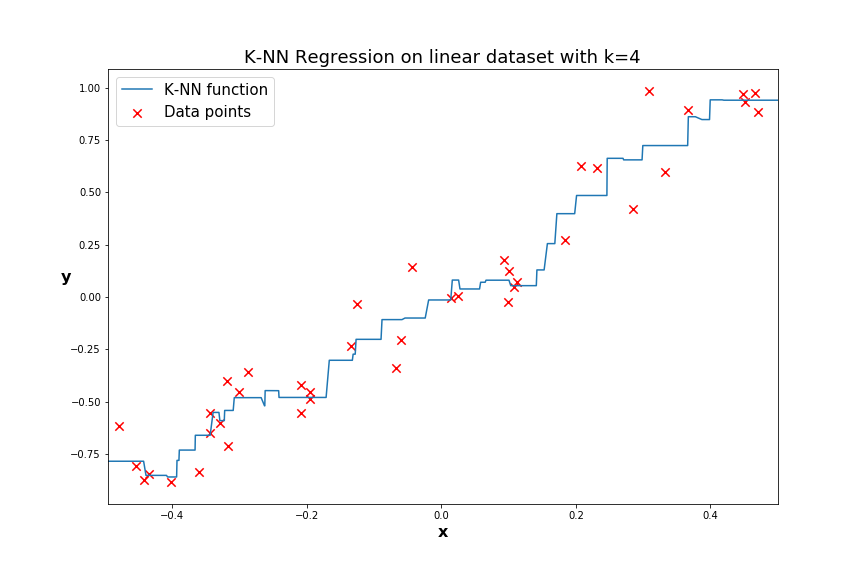   width=600"></p>


    <figcaption>Figure 1: Decision function of K-NN regression</figcaption>
</center>

The red points denotes the stored training data points. Now, as seen in the figure, the decision function of K-NN regression takes **non-linear, discontinuous form as combinations of step functions**. The step functions(sudden change in target values) are the result of abrupt shift in nearest neighbors(change in voters) with respect to feature values.




### Limitation of K-NN Regression's prediction

<center>


<p><img src="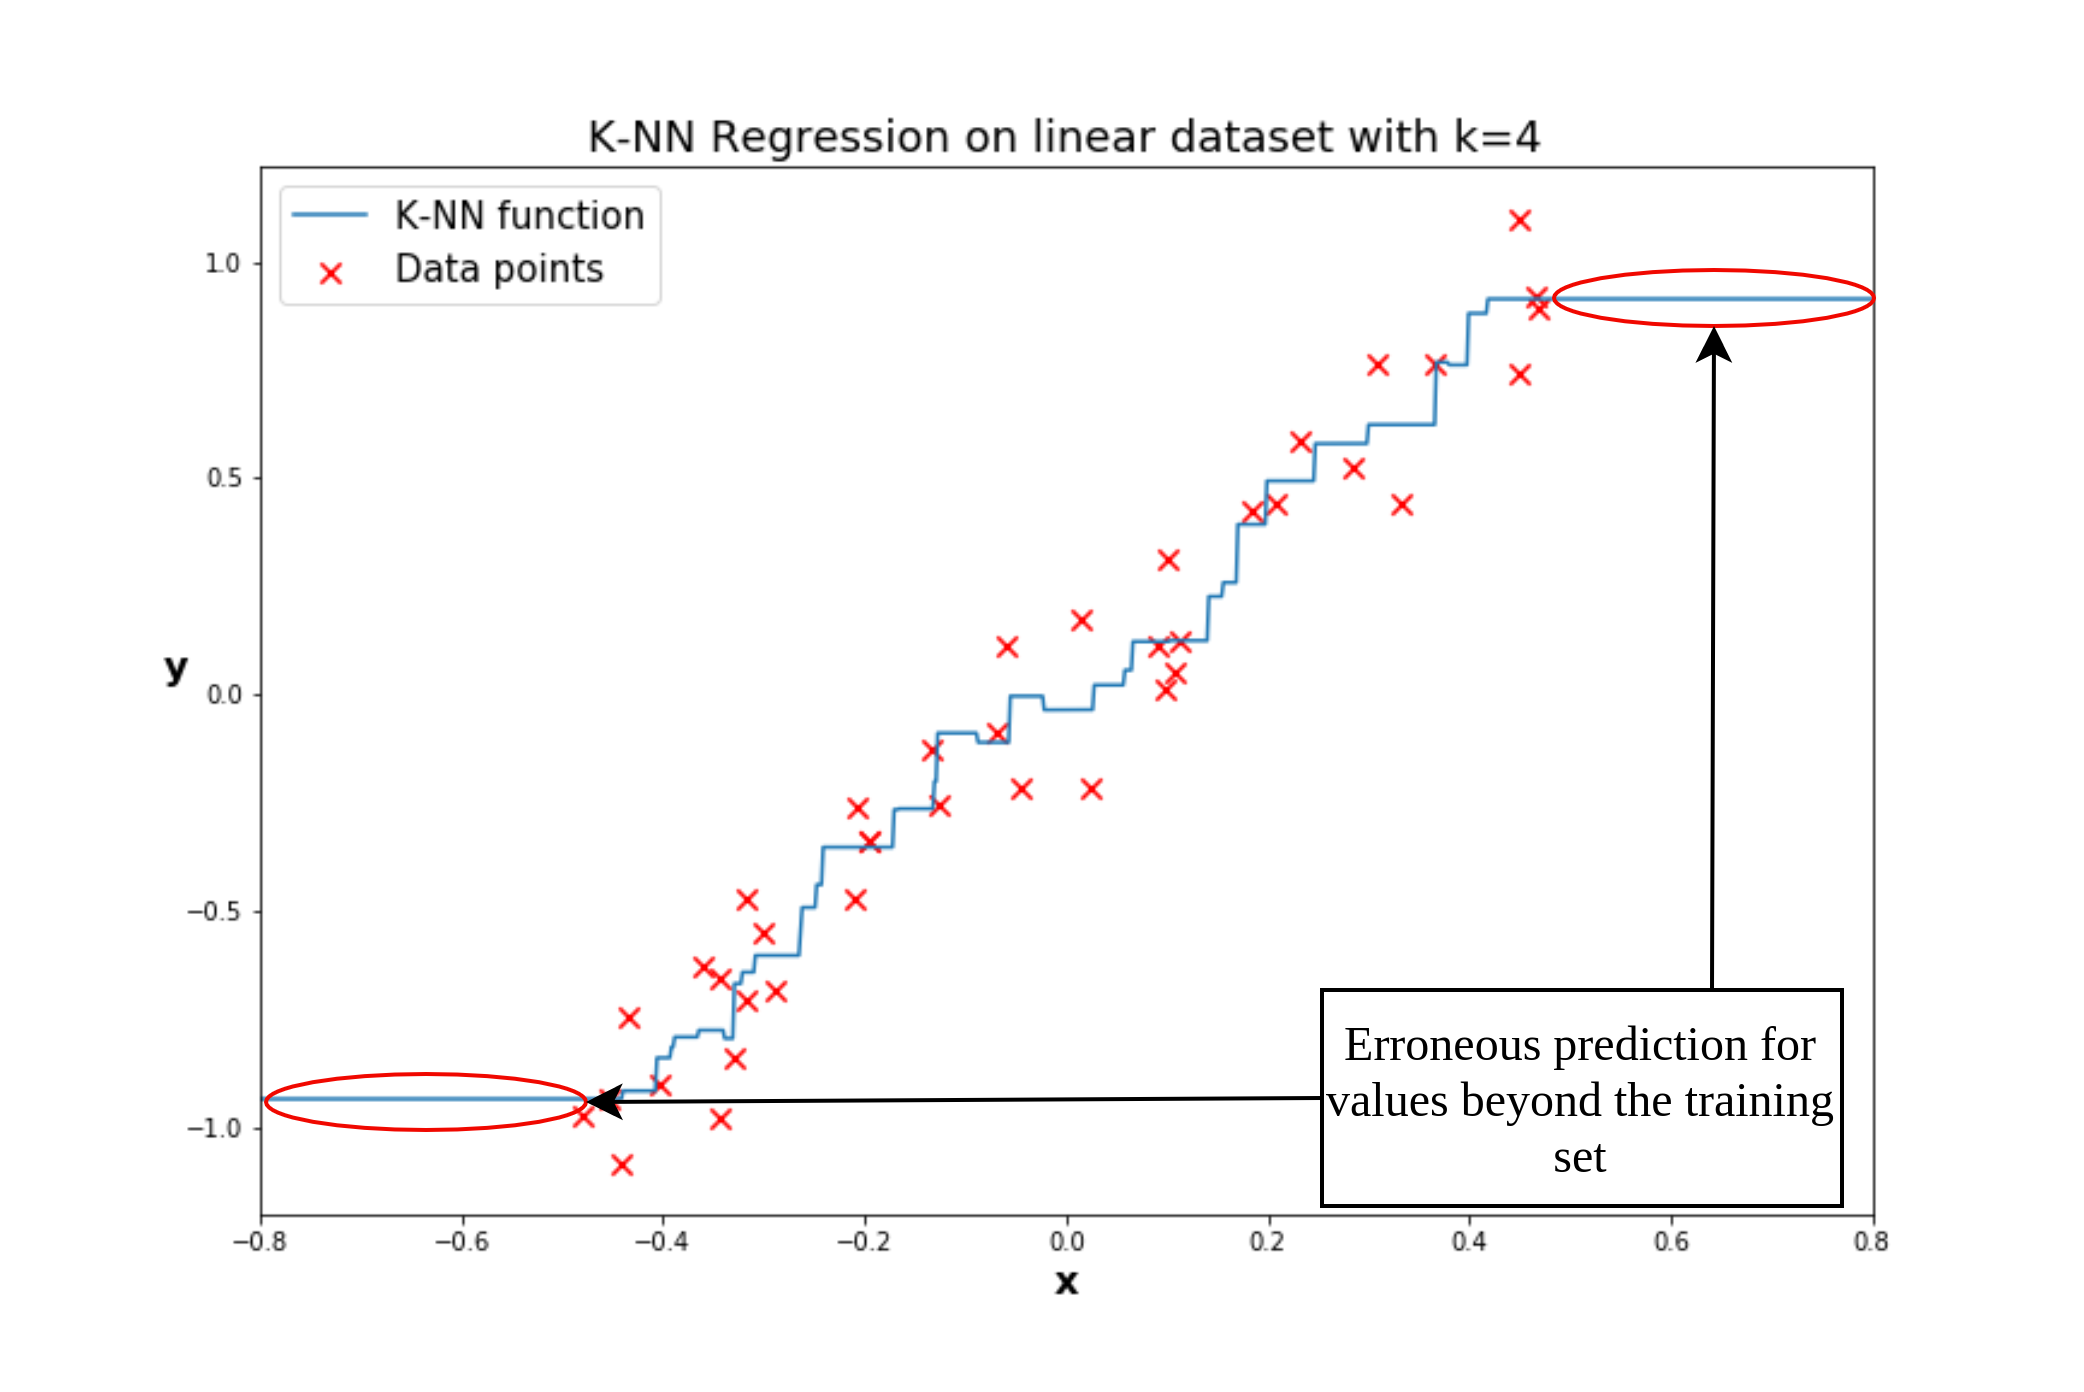   width=650"></p>


    <figcaption>Figure 2: Limitation of K-NN Regression</figcaption>
</center>

Figure 2 shows the prediction from the same K-NN regression as figure 1 for feature values beyond the stored instances. Since, the extreme values of stored sample being between -0.5 and 0.5, new unseen $\mathbf{x}$ greater or less than 0.5 uses those stored sample resulting in constant prediction. _Incorrect prediction for input samples whose magnitude are beyond the stored instance is a major limitation of K-NN regression model_.


## Effects of K in K-NN regression

As K-NN regression is closely related to K-NN classifier, the effect of K value on the decision function is similar. Small value of $K$ results in high variance, low bias regression model, while large value results in low variance, high bias regression model. Figure 2 shows the decision function for different values of $K$ from 1 to 10 fitted on same dataset as figure 1.

<center>


<p><img src="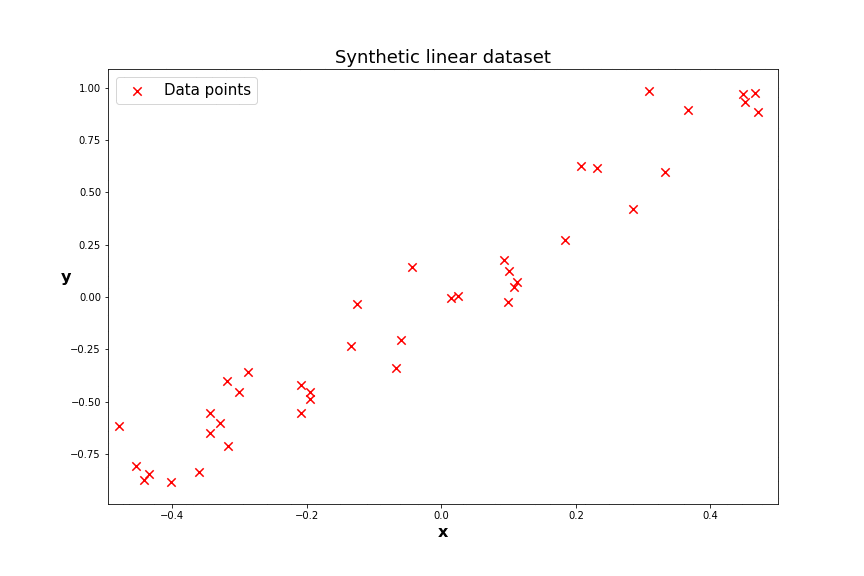   width=600"></p>


    <figcaption>Figure 3: Effect of K on decision function of K-NN regression</figcaption>
</center>

Notice that $K=1$ model fits the dataset perfectly, hitting every training data point with large abrupt changes in target values. This model has large variance because the prediction depends on a single stored training label. Increasing $K$ results in averaging values over neighbor's target value and consequently smoother decision function, as with $K=10$. This model has larger bias than $K=1$. Note: Increasing the value further might mask the original function of the dataset.


## Comparision of Linear regression with K-NN regression

Now that we delved into the working, decision function of K-NN regression model, let's investigate further when one should use K-NN regression by comparing it with the most popular regression algorithm,  linear regression(Not polynomial regression).

Compared to K-NN regression model, linear regression is a parametric model that with linear assumption $f(X)=X\beta$. Though easy to fit with small number of parameters, the disadvantage of parameteric models is the strict assumption of true function $f(X)$ and consequently constant form of hypothesis function $h(X)$. **Parametric models severely decline in performance if the assumption doesn't match the true mapping function of data**. On the other hand, K-NN regression doesn't assume a strict form of $f(X)$, ergo provides more flexible fit for regression problem.


### Linear dataset

Let's compare the two model on same dataset as in figure 1.

<center>


<p><img src="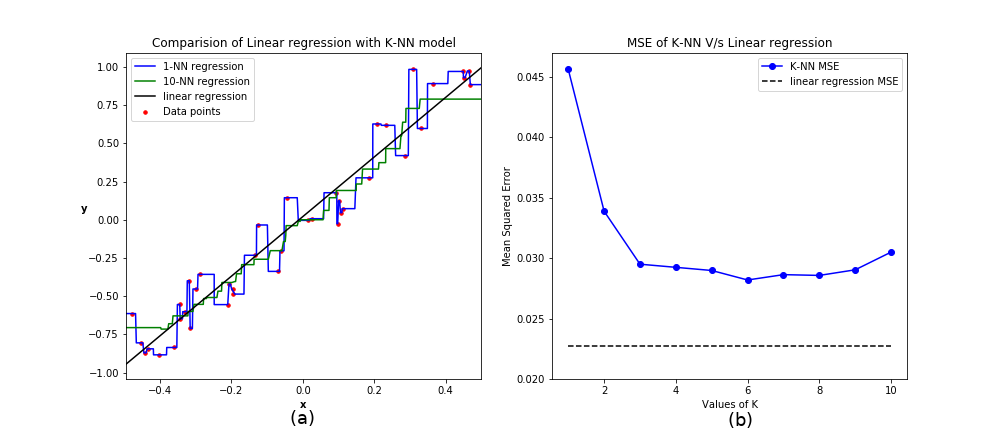  "></p>


    <figcaption>Figure 4: Fit of K-NN and linear regression on dataset having linear relationship between x and y | (a) the decision functions | (b) Mean squared errors</figcaption>
</center>

Figure 4(a) shows the fit of 1-NN, 10-NN and linear regression model on the synthetic dataset with mapping function $y=2\mathbf{x}+noise$. Here, since the assumed form of hypothesis function matches the true mapping function, the linear regression performs better than the more flexible K-NN regression (K-NN incurs a cost in variance that is not offset by a reduction in bias(James, G., (2013), pg 106)), as can be seen on figure 4(b). Figure 4(b) shows the MSE score of various K-NN model and linear regression model. None of the K-NN model (value of $K$ranged from 1 to 10) outform the linear regression model in such scenario.


### Non-linear dataset

Now, let's try the same experiment on non-linear datasets. Note: In figure 5(a), 6(a), the black colored decision function are the true mapping function not the linear regression's decision function. 

Figure 5 shows the experiment, when the dataset is slightly complex with mapping function is $y=\mathbf{x}^3 + \text{noise}$, the linear regression model still outperforms K-NN regression for lower values of $K$. However, as $K$ increases K-NN regression model performs better than simple linear regression.

<center>


<p><img src="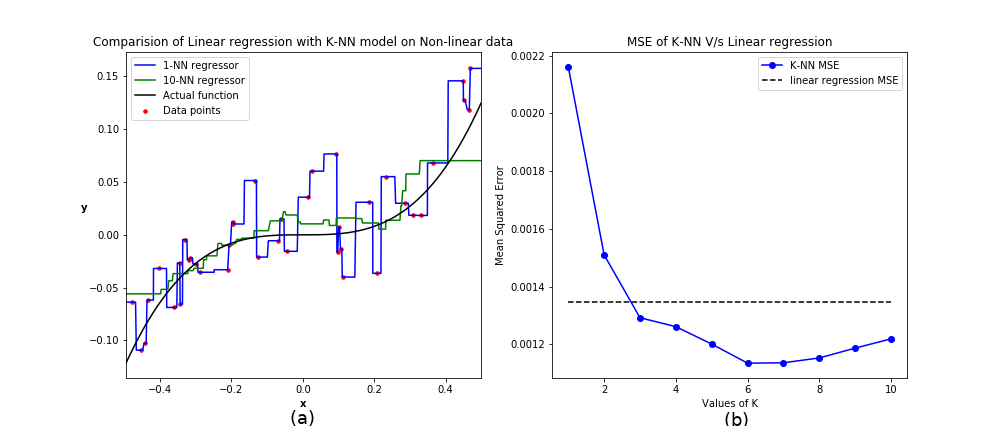  "></p>


    <figcaption>Figure 5: Fit of K-NN and linear regression on dataset with 3rd degree polynomial relation between x and y| (a) the decision function of K-NN and true mapping function | (b) Mean squared errors</figcaption>
</center>

Finally when the dataset is significantly deviated from linearity, say dataset with mapping $y=\mathbf{x}^3+\mathbf{x}^2+noise$, there is substantial change on the model performance. K-NN regression because of its non-parametric nature heavily outperforms linear regression model.

<center>


<p><img src="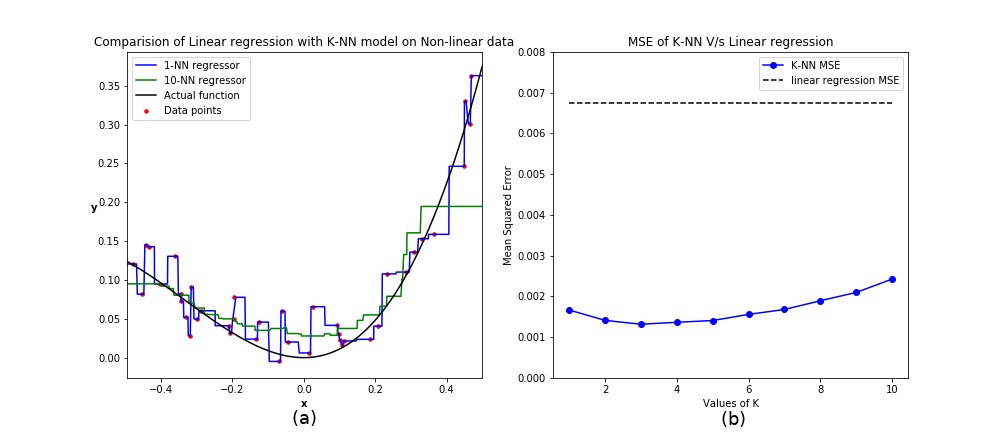  "></p>


    <figcaption>Figure 6: Fit of K-NN and linear regression on complex dataset | (a) the decision function of K-NN and true mapping function | (b) Mean squared errors</figcaption>
</center>

The above cases shows that K-NN is worse than linear regression for dataset with linear relationship but better for non-linear datasets. In real-world since most of the dataset have non-linear relationship between features and variables, one might draw conclusion that K-NN is always a better choice than linear regression. However, it not always the truth, due to curse of dimensionality and sensitivity of noise features, even in non-linear cases, K-NN might perform worse than linear regression model. 



### Effect of large feature dimension and noise variables in K-NN

<center>


<p><img src="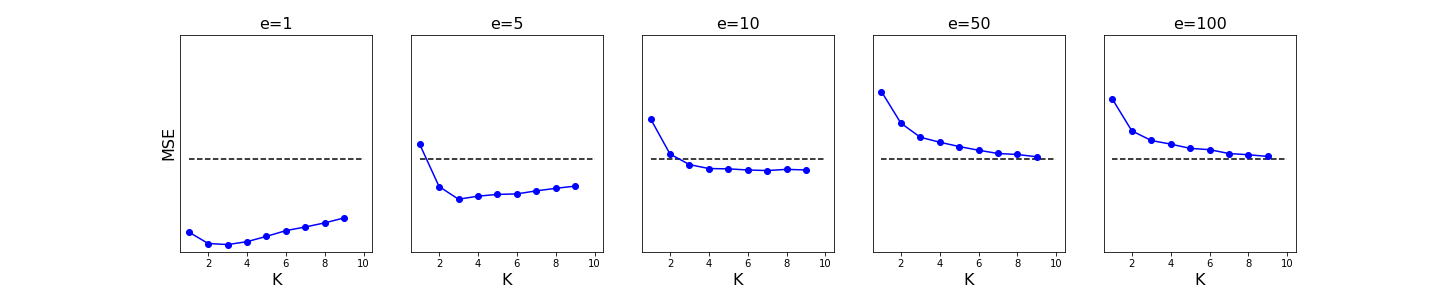 height=220  "></p>


    <figcaption>Figure 7: Effect of high-dimension and noisy features on K-NN and linear regression</figcaption>
</center>

Figure 7 shows the performance of K-NN and linear regression model on the same dataset as figure 6 but with additional noise features added that don't affect the target value. As the number of noise features are denoted by $e$ increases the performance of linear regression model is unaffected, but the performance of K-NN regression deteriorates. Increasing the number of samples in dataset might solve this issue, but is generally cumbersome in real-world.

The main point to note is, even if K-NN performs better than linear regression for non-linear scenario, we prefer linear regression model for higher dimensional dataset with comparatively lower number of datasample. Remember, __parametric models are generally better for smaller ratio of number of samples per feature__. Even _when the feature dimesion is small if the performance of K-NN is slightly greater than linear regression, prefer linear regresssion due to its simplistic interpretability and small number of parameters_.


## Application of K-NN Regression

The decision function of the K-NN regression model is discontinuous, step in nature, therefore, isn't a popular regression algorithm. However, researchers, engineers have used K-NN regression in real-world application due to its simplicity such as:

1. __Missing value imputation__ - Scikit-learn provides K-NN imputer, ```impute.KNNImputer``` that uses K-NN regression to impute missing values of features.


2. __Image reconstruction__ - Corrupt pixels of image is similar to missing feature values. Using K-NN regression one can reconstruct the corrupt pixel leading to image reconstruction. 

  - Check out blakefuller3's blog on [Image reconstruction using KNN algorithm]( https://blakefuller3.wordpress.com/2013/05/28/image-reconstruction-using-knn-algorithm/)

  - 3D reconstruction paper by Zhu, H., et al. (2019) uses KNN, [Paper here]( https://link.springer.com/article/10.1007%2Fs11042-019-7686-1)
  
  
3. Others (Imandoust, S. B., and Bolandraftar, M. (2013))

 - Baseline models
 - Financial sector - Stock market price prediction.
 - Health sector - Estimation of amount of glucose in blood of diabetic person.


## Pros/Cons of K-NN

At the end of this read, let's discuss the pros and cons of entire K-NN algorithm.


### Pros

Following are the pros of using K-NN algorithm:

1. Simplicity - K-NN is an instance-based algorithm which easy to understand and implement. (Majority voting or aggregation).

2. No strict assumption on true mapping function - Works for linear/non-linear dataset. This property acts double-edged sword(as discussed in comparision subsection.)

3. Zero to minute training time 
 - Effective in online-learning scenario, as new data can be seemlessly added(No complete retraining required.)
 
 - Acts base model for initial analysis of dataset before running more complex algorithm.


4. In comparision to other algorithms, generalizes to multi-class classification problem without additional settings.



### Cons

Following points represent the cons of using K-NN algorithm:

1. Poor performance for large dimensional feature space(due to curse of dimensionality.)

2. Requires of domain knowledge for selection of distance metric and optimal value of $K$.

3. Needs homogeneous features for optimal performance, i.e. feature magnitude must be scaled.

3. Sensitivity to data with noise, missing values and outliers.

    - K-NN based models require careful preprocessing steps such as feature scaling, outlier handling, etc. else the performance degrades substantially.


That's all for the read in K-NN unit. Next, we are discussing programming material of K-NN, where you will learn the things to consider while using K-NN algorithm such as how to select optimal $K$, effect of unscaled, noisy features, importance of preprocessing and learn improvement of K-NN, known as weighted K-NN.


## Key-Takeaways

The main points to remember from this notebooks are:

1. K-NN Regressor is similar to K-NN classifier. The difference is the prediction phase, where K-NN regression:

   - Predicts new sample's ($\mathbf{x}_t$) target value ($h(\mathbf{x}_t)$) by computing the "$K$" nearest neighbors ($S_{\mathbf{x}_t}$) among stored training set then taking average of the neighbors target values(aggregation scheme.)
    
    $$h(\mathbf{x}_t) = \frac{\sum_{y'' \in S_{\mathbf{x}_t}} y''}{K}$$
    
    
2. K-NN Regression's decision function has non-linear and discontinuous form - combination of step functions. Also, K-NN regression gives errorneous predictions for feature values far away from the stored instance's features.


3. $K$ values affects K-NN regression similar to K-NN classifier.
 - Small $K$ - High variance, low bias model.
 - Large $K$ - Low variance, high bias model.
 
 
4. When the true mapping function of dataset matches the assumption of parametric models(linear regression), they outperform non-parametric models(K-NN regression). Along with this, parametric models are also better for smaller ratio of number of samples per feature. 


5. Even for smaller feature dimension if the performance of K-NN regression is slightly greater than linear regression, prefer linear regresssion due to its simplistic interpretability and small number of parameters.


6. Though unpopular, K-NN regression are used for missing value imputations and image reconstructions.


7. Simplicity, dynamic hypothesis function, faster training, and multi-class generalization are pros of K-NN model, while poor performance in high feature dimension, proper domain knowledge, sensitivity to feature scale, noise and missing values are its cons.


## References

- Books
 1. James, G., Witten, D., Hastie, T. and Tibshirani, R. (2013), An introduction to statistical learning, Chapter 3 - Linear regression, pg 104-109.
 
- Papers
 1. Imandoust, S. B. and Bolandraftar, M. (2013), Application of K-Nearest Neighbor (KNN) Approach for Predicting Economic Events: Theoretical Background, International journal of engineering research and applications, 605-610, Retrieved from: https://www.researchgate.net/publication/304826093_Application_of_K-nearest_neighbor_KNN_approach_for_predicting_economic_events_theoretical_background
 
 2. Zhu, H., Yang, T., Yang, P. et al. (2019), 3D reconstruction for ultrasonic C-scan images of tissue-mimicking phantom based on an improved K-nearest neighbor filtering. Multimed Tools Appl 78, 23597–23616, DOI:  https://doi.org/10.1007/s11042-019-7686-1


## Additional material

- Web article
 - Scikit learn's article on [Face completion with a multi-output estimators]( https://scikit-learn.org/stable/auto_examples/miscellaneous/plot_multioutput_face_completion.html#sphx-glr-auto-examples-miscellaneous-plot-multioutput-face-completion-py)
